## Simulation Fermi paradox

Here we want to simulate the appearance of life of the Fermi paradox.

We consider $D$ the traveled distance of a civilization since it appeared. If we supposed that all civilizations have a uniform distribution, and they extend like spheres, we have $D = 2r$ with $r$ the radius of the sphere of the occupation for each civilizations. 

Then we have :
$$$$

In [4]:
"""
Created on Sun Mar 20 20:39:04 2022

@author: Xavier Corap
"""

import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches
import functions as fs

Here are all constants of the equation of drake (taken here https://fr.wikipedia.org/wiki/%C3%89quation_de_Drake) and constants for considering our galaxie.


In [5]:
Rp=10 ##en année
fp=0.5
ne=2
fl=1
fi=0.01
fc=0.01
Rg=15 ##en kpc
h=1 ##en kpc
annee=31536000 ##seconde par an
c=300000*annee/3.09e16 ##vitesse de la lumière en kilo parsec par année
Rastro=Rp*fp*ne
fbiot=fl*fi*fc
N=10 ##nombre de civilisation
##coordonnées du soleil 
soleil=[0,8.5,0]

A plot that show the evolution of the distance between each civilization by considering them with a uniform distrubution and the number of civilization over the meaning duration of civilizations.

c:\Users\Xavier Corap\Documents\Projets\Fermi_paradox\functions.py:32: RuntimeWarning: divide by zero encountered in divide
  return 2*(3*h*Rg**2/(4*Rastro*fbiot*L))**(1/3)
c:\Users\Xavier Corap\Documents\Projets\Fermi_paradox\functions.py:35: RuntimeWarning: divide by zero encountered in divide
  return 2*Rg/np.sqrt(Rastro*fbiot*L)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


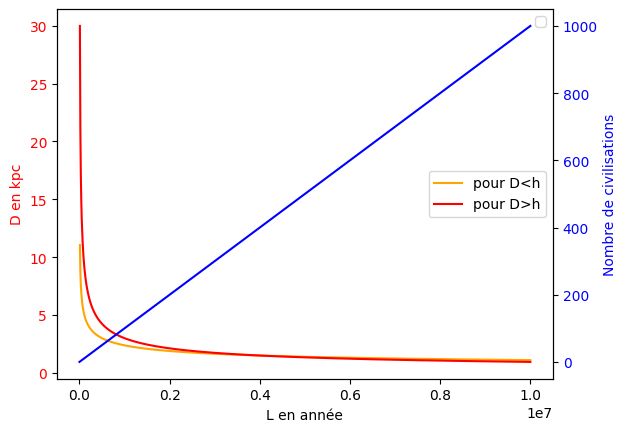

In [6]:
L=np.linspace(0,1e7,1000)


fig, ax1 = plt.subplots() 
  
ax1.set_xlabel('L en année') 
ax1.set_ylabel('D en kpc', color = 'red') 
ax1.plot(L, fs.D1(L), color = 'orange',label='pour D<h') 
ax1.plot(L, fs.D2(L), color = 'red',label="pour D>h") 

ax1.tick_params(axis ='y', labelcolor = 'red') 
ax1.legend(loc='right')

ax2 = ax1.twinx() 
  
ax2.set_ylabel('Nombre de civilisations', color = 'blue') 
ax2.plot(L, fs.N(L), color = 'blue') 
ax2.tick_params(axis ='y', labelcolor = 'blue') 
ax2.legend()
plt.show()

Here we consider that civilizations extend with a constant speed over year, and we consider a cylindric galaxy. For each iteration, there is a probability that a civilization spawns on random coordinates in the galaxy

0.1


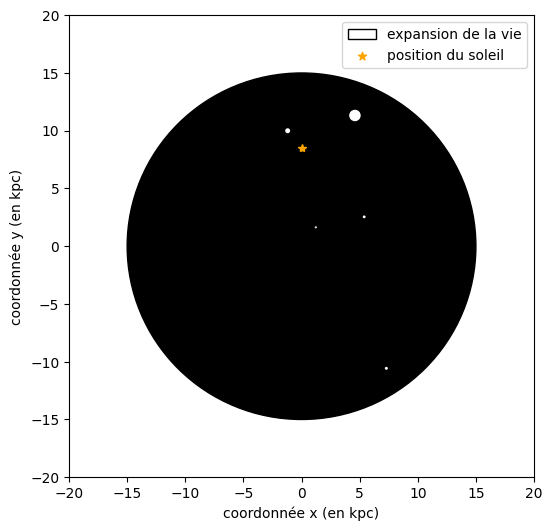

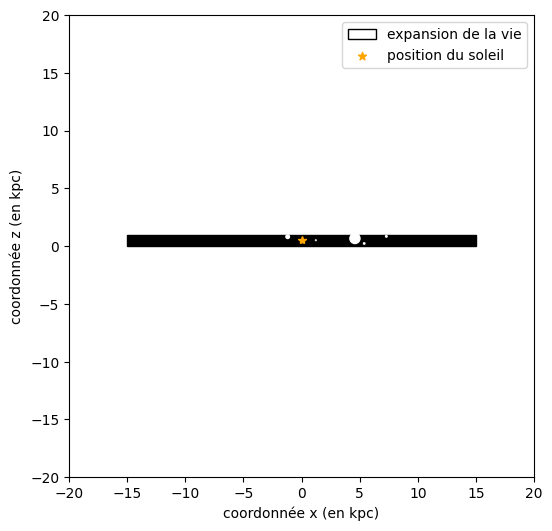

In [7]:
x=np.linspace(-1,1,100)
z=np.linspace(0,1,100)
Xc, Zc=np.meshgrid(x, z)
Yc = np.sqrt(1-Xc**2)
Xc=15*Xc
Yc=15*Yc

pas=100
p=Rp*fp*ne*fl*fi*fc*pas
#On vérifie que p<=1
print(p)
L=10000
v=0.2*c
e=np.array([[0,0,0,0,0]])
for t in range (0,500000,pas):
    p2=np.random.uniform(0,1)
    if (p2<p):
        rrand=np.random.uniform(0,15)
        thetarand=np.random.uniform(0,2*np.pi)
        zrand=np.random.uniform(0,1)
        e=np.append(e,[[rrand*np.cos(thetarand),rrand*np.sin(thetarand),zrand,0,0]],axis=0)
        for i in range (0,len(e)):
            e[i][3]=e[i][3]+pas*v
            e[i][4]=e[i][4]+pas
        e=e[e[:,4]<L]
                
    else:
        for i in range (0,len(e)):
            e[i][3]=e[i][3]+pas*v
            e[i][4]=e[i][4]+pas
        e=e[e[:,4]<L]

plt.figure(figsize=(6,6))        
ax2=plt.gca()

cercle2=plt.Circle((0,0),15,color='black')
ax2.add_artist(cercle2)

ax2.plot(soleil[0],soleil[1],'*',color='orange',label='position du soleil')
l1=mpatches.Patch(color='black',alpha=1,fill=False)
l12=plt.scatter([],[],marker='*',color='orange')
ax2.legend([l1,l12],['expansion de la vie','position du soleil'])

plt.figure(figsize=(6,6))        
ax3=plt.gca()
ax3.add_patch(Rectangle((-15,0),30,1,color='black'))
ax3.plot(soleil[0],soleil[2]+0.5,'*',color='orange',label='position du soleil')
l1=mpatches.Patch(color='black',alpha=1,fill=False)
l12=plt.scatter([],[],marker='*',color='orange')
ax3.legend([l1,l12],['expansion de la vie','position du soleil'])


U=np.linspace(0,2*np.pi,100)
V=np.linspace(0,np.pi,100)
for i in range (0,len(e)):
    u, v = np.meshgrid(U, V)
    x = e[i][3]*np.cos(u)*np.sin(v)+e[i][0]
    y = e[i][3]*np.sin(u)*np.sin(v)+e[i][1]
    z = e[i][3]*np.cos(v)+e[i][2]
    cercle=plt.Circle((e[i][0],e[i][1]),e[i][3],color='white')
    cercle2=plt.Circle((e[i][0],e[i][2]),e[i][3],color='white')
    ax2.add_artist(cercle)
    ax3.add_artist(cercle2)

ax2.set_xlim(-20,20)
ax2.set_ylim(-20,20)
ax2.set_xlabel('coordonnée x (en kpc)')
ax2.set_ylabel('coordonnée y (en kpc)')


ax3.set_xlim(-20,20)
ax3.set_ylim(-20,20)
ax3.set_xlabel('coordonnée x (en kpc)')
ax3.set_ylabel('coordonnée z (en kpc)')


plt.show()


Here is the number of civilizations over meaning duration of civilizations for different probability of spawn

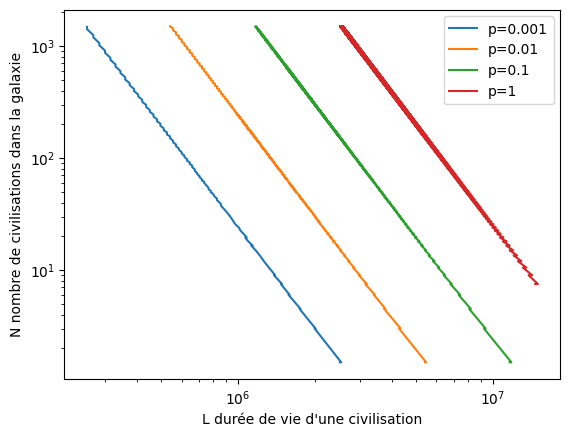

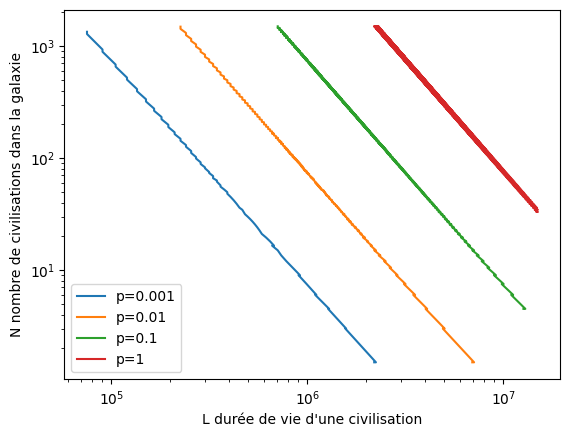

In [8]:
Rastro=1

Vg=np.pi*Rg**2*h

L=np.linspace(0,1.5e7,1000)
N=Rastro*fbiot*L
plt.figure()
plt.plot(fs.contact(L,N,0.001,0.00105,fs.Vmoy1)[0],fs.contact(L,N,0.001,0.00105,fs.Vmoy1)[1],label="p=0.001")
plt.plot(fs.contact(L,N,0.01,0.0105,fs.Vmoy1)[0],fs.contact(L,N,0.01,0.0105,fs.Vmoy1)[1],label="p=0.01")
plt.plot(fs.contact(L,N,0.1,0.105,fs.Vmoy1)[0],fs.contact(L,N,0.1,0.105,fs.Vmoy1)[1],label="p=0.1")
plt.plot(fs.contact(L,N,1,1.105,fs.Vmoy1)[0],fs.contact(L,N,1,1.105,fs.Vmoy1)[1],label="p=1")
plt.xlabel("L durée de vie d'une civilisation")
plt.ylabel("N nombre de civilisations dans la galaxie")
plt.xscale("log")
plt.yscale("log")
plt.legend()

plt.figure()
plt.plot(fs.contact(L,N,0.001,0.00105,fs.Vmoy2)[0],fs.contact(L,N,0.001,0.00105,fs.Vmoy2)[1],label="p=0.001")
plt.plot(fs.contact(L,N,0.01,0.0105,fs.Vmoy2)[0],fs.contact(L,N,0.01,0.0105,fs.Vmoy2)[1],label="p=0.01")
plt.plot(fs.contact(L,N,0.1,0.105,fs.Vmoy2)[0],fs.contact(L,N,0.1,0.105,fs.Vmoy2)[1],label="p=0.1")
plt.plot(fs.contact(L,N,1,1.105,fs.Vmoy2)[0],fs.contact(L,N,1,1.105,fs.Vmoy2)[1],label="p=1")
plt.xlabel("L durée de vie d'une civilisation")
plt.ylabel("N nombre de civilisations dans la galaxie")
plt.xscale("log")
plt.yscale("log")
plt.legend()


Now we consider a galaxy model more realistic with spirals 

In [14]:
a=1.64
b=4.01
R1=0.55
R0=8.5
k=[4.25,4.25,4.89,4.89]
r0=[3.48,3.48,4.90,4.90]
theta0=[1.57,4.71,4.09,0.95]

pas=100
p=Rp*fp*ne*fl*fi*fc*pas
L=10000
v=0.1*c
vie=np.array([[0,0,0,0,0]])
for t in range (0,500000,pas):
    pvie=np.random.uniform(0,1)
    if pvie<=p:
        bras=int(np.random.uniform(0,4))
        r=np.random.exponential(3)
        theta=fs.te(r,k[bras],r0[bras],theta0[bras])
        theta=theta+np.random.uniform(0,2*np.pi)*np.exp(-r*0.35)
        r=r+np.random.normal(0,0.07*r)
        z=np.random.choice([-1,1])*np.random.exponential(0.05)
        vie=np.append(vie,[[r*np.cos(theta),r*np.sin(theta),z,0,0]],axis=0)
    for i in range (0,len(vie)):
            vie[i][3]=vie[i][3]+pas*v
            vie[i][4]=vie[i][4]+pas
    vie=vie[vie[:,4]<L]
           



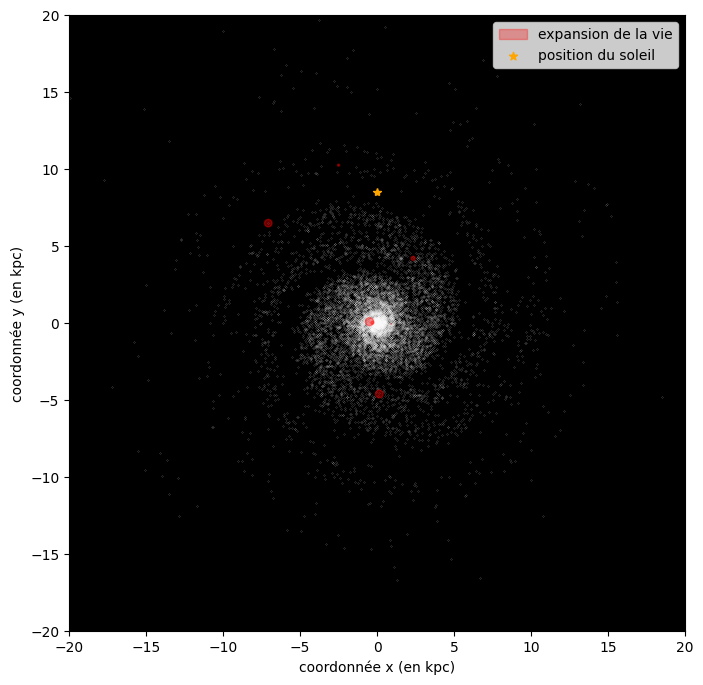

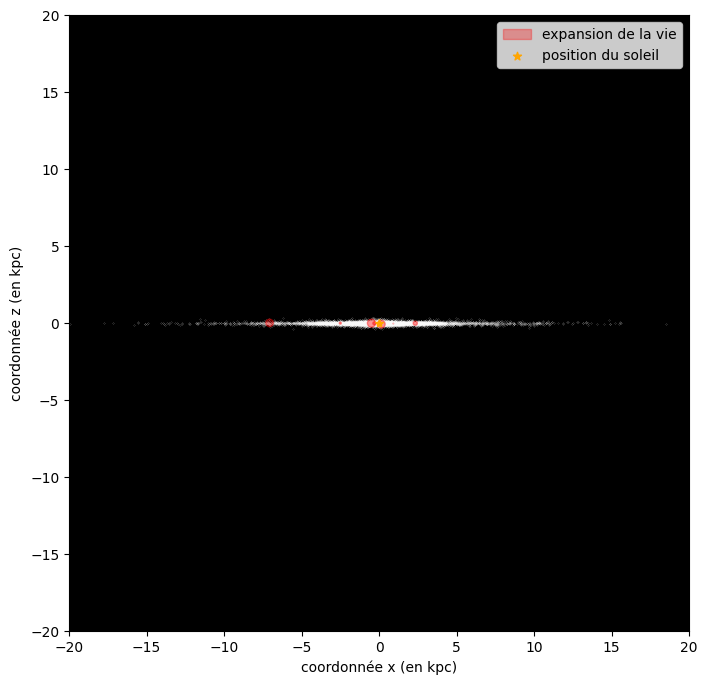

In [18]:
r=np.linspace(0,10,1000)

plt.figure(figsize=(8,8))
ax2=plt.gca()
plt.figure(figsize=(8,8))
ax3=plt.gca()
r1,r2,r3,r4,t1,t2,t3,t4=fs.erand(k,r0,theta0,10000)
x1,y1=fs.xy(r1,t1)
x2,y2=fs.xy(r2,t2)
x3,y3=fs.xy(r3,t3)
x4,y4=fs.xy(r4,t4)
z1=fs.zal(np.random.exponential(0.05,len(x1)))
z2=fs.zal(np.random.exponential(0.05,len(x2)))
z3=fs.zal(np.random.exponential(0.05,len(x3)))
z4=fs.zal(np.random.exponential(0.05,len(x4)))


## Je trace ici mes sphères et mes disques pour mes schémas en 3D et 2D
U=np.linspace(0,2*np.pi,100)
V=np.linspace(0,np.pi,100)
ax2.scatter(x1,y1,s=0.01,c='white')
ax2.scatter(x2,y2,s=0.01,c='white')
ax2.scatter(x3,y3,s=0.01,c='white')
ax2.scatter(x4,y4,s=0.01,c='white')

ax3.scatter(x1,z1,s=0.01,c='white')
ax3.scatter(x2,z2,s=0.01,c='white')
ax3.scatter(x3,z3,s=0.01,c='white')
ax3.scatter(x4,z4,s=0.01,c='white')

for i in range (0,len(vie)):
    u, v = np.meshgrid(U, V)
    x = vie[i][3]*np.cos(u)*np.sin(v)+vie[i][0]
    y = vie[i][3]*np.sin(u)*np.sin(v)+vie[i][1]
    z = vie[i][3]*np.cos(v)+vie[i][2]
    cercle=plt.Circle((vie[i][0],vie[i][1]),vie[i][3],color='red',fill=True,alpha=0.4)
    cercle2=plt.Circle((vie[i][0],vie[i][2]),vie[i][3],color='red',fill=True,alpha=0.4)
    ax2.add_artist(cercle)
    ax3.add_artist(cercle2)
ax2.set_aspect(1)
ax2.set_xlim(-20,20)
ax2.set_xlabel('coordonnée x (en kpc)')
ax2.set_ylabel('coordonnée y (en kpc)')
ax2.set_ylim(-20,20)
ax2.set_facecolor('black')
l1=mpatches.Patch(color='red',alpha=0.3,label='expansion de la vie')
l12=plt.scatter([],[],marker='*',color='orange')
ax2.plot(soleil[0],soleil[1],'*',color='orange')
ax2.legend([l1,l12],['expansion de la vie','position du soleil'])



ax3.set_xlim(-20,20)
ax3.set_xlabel('coordonnée x (en kpc)')
ax3.set_ylabel('coordonnée z (en kpc)')
ax3.set_ylim(-20,20)
ax3.set_facecolor('black')
ax3.plot(soleil[0],soleil[2],'*',color='orange')
ax3.legend([l1,l12],['expansion de la vie','position du soleil'])




plt.show()